# Learning quantum kernels from data

[![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LegacYFTw/ece592-fall-2026/blob/main/learned_quantum_kernels.ipynb)

A quantum kernel does not appear independently of the data encoding. Once an encoding circuit and a rule for comparing quantum states have been selected, the kernel is mathematically determined.

This notebook studies three questions:

- How do we propose or select a kernel?
- What does the classifier actually learn after receiving the kernel?
- How do trainable encodings and kernel classifiers influence one another?

We will use one binary Iris classification task throughout the notebook.

## Notebook overview

```mermaid
flowchart TD
    A["Classical training data"] --> B["Choose an encoding architecture Uφ(x; θ)"]
    B --> C["Prepare encoded states |φθ(x)⟩"]
    C --> D["Fidelity rule determines Kθ(x,z)"]
    D --> E["Construct the Gram matrix"]
    E --> F["SVM learns coefficients α and intercept b"]
    F --> G["Decision function fθ(x)"]

    B --> H["Architecture fixes the kernel family"]
    H --> I["Optional trainable parameters θ"]
    I --> J["Evaluate a label-dependent kernel loss"]
    J --> K["Update θ"]
    K --> D

    classDef data fill:#DCEBFA,stroke:#2A6FDB,stroke-width:2px,color:#111111
    classDef encoding fill:#EEE2FA,stroke:#7A3EB1,stroke-width:2px,color:#111111
    classDef kernel fill:#DDF3E8,stroke:#248A5B,stroke-width:2px,color:#111111
    classDef classifier fill:#FCE7D8,stroke:#D66A22,stroke-width:2px,color:#111111
    classDef optimization fill:#FFF2CC,stroke:#C69214,stroke-width:2px,color:#111111

    class A data
    class B,C,H,I encoding
    class D,E kernel
    class F,G classifier
    class J,K optimization
```

## What is a kernel?

Let $\mathcal{X}$ denote the input space. In this notebook, each point $x\in\mathcal{X}$ represents the scaled petal length and petal width of an Iris flower.

A real-valued function

$$
K:\mathcal{X}\times\mathcal{X}\rightarrow\mathbb{R}
$$

is a valid kernel if it satisfies two conditions.

### Symmetry

For every pair $x,z\in\mathcal{X}$,

$$
K(x,z)=K(z,x).
$$

The similarity between $x$ and $z$ must therefore be independent of the order in which the two points are supplied.

### Positive semidefiniteness

For every finite collection of points $x_1,\ldots,x_m\in\mathcal{X}$ and every vector of real coefficients $c=(c_1,\ldots,c_m)^T\in\mathbb{R}^m$,

$$
\sum_{i=1}^{m}\sum_{j=1}^{m}c_i c_j K(x_i,x_j)\geq 0.
$$

For the selected data points, define the Gram matrix $G\in\mathbb{R}^{m\times m}$ by

$$
G_{ij}=K(x_i,x_j).
$$

The positive-semidefinite condition is equivalent to requiring

$$
c^T G c\geq 0
$$

for every $c\in\mathbb{R}^m$. Equivalently, every eigenvalue of $G$ must be nonnegative.

A function that merely assigns a large value to similar points is not automatically a valid kernel. It must produce a positive-semidefinite Gram matrix for every possible finite dataset.

## Kernels as inner products in a feature space

A positive-semidefinite kernel can be represented as an inner product in some feature space. There exists a map

$$
\Phi:\mathcal{X}\rightarrow\mathcal{H}
$$

from the original input space into a Hilbert space $\mathcal{H}$ such that

$$
K(x,z)=\langle\Phi(x),\Phi(z)\rangle_{\mathcal{H}}.
$$

The map $\Phi$ may be nonlinear and the feature space may have a very large or even infinite dimension. A kernel method does not need to construct $\Phi(x)$ explicitly. It only needs to evaluate the inner products $K(x,z)$.

For example, the classical radial-basis-function kernel is

$$
K_{\mathrm{RBF}}(x,z)=\exp\left(-\gamma\lVert x-z\rVert^2\right).
$$

It assigns large similarity to nearby points and smaller similarity to distant points.

## What the classifier learns

Once a kernel has been chosen, a kernel support-vector machine constructs a decision function of the form

$$
f(x)=\sum_{i=1}^{m}\alpha_i y_i K(x_i,x)+b,
$$

where $x_i$ are training examples and $y_i\in\{-1,+1\}$ are their labels.

The classifier learns the coefficients $\alpha_i$ and the intercept $b$. It does **not** infer the formula for $K$. The kernel determines how the data are represented, while the classifier learns a separating function within the resulting kernel feature space.

The predicted class is determined by the sign of the decision function:

$$
\widehat{y}(x)=\operatorname{sign}(f(x)).
$$

Consequently, changing the kernel changes the family of decision functions available to the classifier.

## Quantum encodings define quantum kernels

A quantum encoding circuit maps a classical input $x$ to a quantum state

$$
|\phi(x)\rangle=U_{\phi}(x)|0\rangle^{\otimes n}.
$$

The corresponding density operator is

$$
\rho_{\phi}(x)=|\phi(x)\rangle\langle\phi(x)|.
$$

We can treat $\rho_{\phi}(x)$ as a feature vector in the Hilbert space of operators equipped with the Hilbert--Schmidt inner product. This produces the fidelity kernel

$$
K_{\phi}(x,z)=\operatorname{Tr}\left[\rho_{\phi}(x)\rho_{\phi}(z)\right].
$$

For pure encoded states,

$$
K_{\phi}(x,z)=\left|\langle\phi(x)|\phi(z)\rangle\right|^2.
$$

Substituting the encoding circuits gives

$$
K_{\phi}(x,z)=\left|\langle 0|^{\otimes n}U_{\phi}(x)^{\dagger}U_{\phi}(z)|0\rangle^{\otimes n}\right|^2.
$$

This equation shows that the kernel is completely determined once we specify:

- the encoding circuit $U_{\phi}(x)$;
- the state-comparison rule, which here is fidelity.

The fidelity kernel is positive semidefinite because, for arbitrary coefficients $c_1,\ldots,c_m$,

$$
\sum_{i,j}c_i c_j K_{\phi}(x_i,x_j)
=
\operatorname{Tr}\left[\left(\sum_i c_i\rho_{\phi}(x_i)\right)^2\right]
=
\left\lVert\sum_i c_i\rho_{\phi}(x_i)\right\rVert_{\mathrm{HS}}^2
\geq 0.
$$

Therefore, a quantum encoding does more than place classical data into a quantum circuit. It defines the geometry seen by the classifier:

$$
\text{encoding}
\longrightarrow
\text{encoded states}
\longrightarrow
\text{pairwise fidelities}
\longrightarrow
\text{Gram matrix}
\longrightarrow
\text{classifier}.
$$

If two inputs are mapped to identical quantum states up to a global phase, their fidelity is one and the kernel cannot distinguish them. If the encoding maps different classes into geometrically distinct regions of state space, the induced kernel may make those classes easier to separate.

In [4]:
import subprocess
import sys

RUNNING_IN_COLAB = "google.colab" in sys.modules
COLAB_REQUIREMENTS_URL = "https://raw.githubusercontent.com/LegacYFTw/ece592-fall-2026/main/requirements-colab.txt"

if RUNNING_IN_COLAB:
    print("Google Colab detected. Installing the course dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "--requirement", COLAB_REQUIREMENTS_URL])
    print("Installation complete.")
else:
    print("Local environment detected. Dependency installation was skipped.")

Local environment detected. Dependency installation was skipped.


In [5]:
from pathlib import Path
from time import perf_counter

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityStatevectorKernel, TrainableFidelityStatevectorKernel
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils.loss_functions import SVCLoss
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

# From a classical feature map to a kernel

A classical feature map sends an input $x\in\mathcal{X}$ into an inner-product space $\mathcal{H}$,

$$
\Phi:\mathcal{X}\longrightarrow\mathcal{H}.
$$

The corresponding kernel is

$$
K(x,z)=\langle\Phi(x),\Phi(z)\rangle_{\mathcal{H}}.
$$

Once $\Phi$ has been selected, the kernel is fixed. It measures similarity using the geometry created by $\Phi$.

## Quantum feature maps

A quantum encoding maps a classical input $x$ to a normalized quantum state,

$$
|\phi(x)\rangle=U_\phi(x)|0\rangle^{\otimes n}.
$$

The corresponding density operator is

$$
\rho_\phi(x)=|\phi(x)\rangle\langle\phi(x)|.
$$

The space of operators has the Hilbert–Schmidt inner product

$$
\langle A,B\rangle_{\mathrm{HS}}=\operatorname{Tr}(A^\dagger B).
$$

Applying this inner product to the encoded density operators gives

$$
\begin{aligned}
K_\phi(x,z)
&=
\operatorname{Tr}\left[\rho_\phi(x)\rho_\phi(z)\right] \\
&=
\operatorname{Tr}\left[
|\phi(x)\rangle
\langle\phi(x)|\phi(z)\rangle
\langle\phi(z)|
\right] \\
&=
\langle\phi(x)|\phi(z)\rangle
\langle\phi(z)|\phi(x)\rangle \\
&=
\left|\langle\phi(x)|\phi(z)\rangle\right|^2.
\end{aligned}
$$

Equivalently,

$$
K_\phi(x,z)
=
\left|
\langle 0|
U_\phi(x)^\dagger U_\phi(z)
|0\rangle
\right|^2.
$$

After $U_\phi$ and the fidelity comparison have been selected, there is no additional kernel-guessing step. The kernel follows directly from the encoding.

## Why is the fidelity kernel valid?

For samples $x_1,\ldots,x_m$ and arbitrary coefficients $c_1,\ldots,c_m$,

$$
\begin{aligned}
\sum_{i,j=1}^{m}c_i^*c_jK_\phi(x_i,x_j)
&=
\sum_{i,j=1}^{m}
c_i^*c_j
\operatorname{Tr}\left[\rho_\phi(x_i)\rho_\phi(x_j)\right] \\
&=
\operatorname{Tr}\left[
\left(\sum_i c_i\rho_\phi(x_i)\right)^\dagger
\left(\sum_j c_j\rho_\phi(x_j)\right)
\right] \\
&=
\left\|
\sum_i c_i\rho_\phi(x_i)
\right\|_{\mathrm{HS}}^2 \\
&\geq 0.
\end{aligned}
$$

Therefore, every Gram matrix with entries

$$
K_{ij}=K_\phi(x_i,x_j)
$$

is positive semidefinite.

For normalized pure states,

$$
0\leq K_\phi(x,z)\leq 1,
\qquad
K_\phi(x,x)=1.
$$

A kernel may be mathematically valid while still being useless for classification.

In [7]:
#dataset setup
dataset_directory = Path(kagglehub.dataset_download("uciml/iris"))
iris_csv_path = next(dataset_directory.rglob("Iris.csv"))
iris = pd.read_csv(iris_csv_path)

print("Dataset file:", iris_csv_path)
print("Original shape:", iris.shape)

Dataset file: /Users/tchatterjee/.cache/kagglehub/datasets/uciml/iris/versions/2/Iris.csv
Original shape: (150, 6)


In [13]:
SEED = 17
TEST_SIZE = 0.25

N_KERNEL_TRAINING_SAMPLES_PER_CLASS = 20
KERNEL_TRAINING_MAXITER = 30
SVC_C = 1.0

FEATURE_COLUMNS = ["PetalLengthCm", "PetalWidthCm"]

SPECIES_TO_LABEL = {
    "Iris-versicolor": 0,
    "Iris-virginica": 1,
}

CLASS_COLORS = {
    0: "#2A6FDB",
    1: "#E4572E",
}

In [14]:
required_columns = FEATURE_COLUMNS + ["Species"]

data = iris.loc[iris["Species"].isin(SPECIES_TO_LABEL), required_columns].copy()
data = data.dropna().reset_index(drop=True)
data["label"] = data["Species"].map(SPECIES_TO_LABEL).astype(int)

X = data[FEATURE_COLUMNS].to_numpy(dtype=float)
y = data["label"].to_numpy(dtype=int)

display(data.head())

print("\nClass counts:")
print(data["Species"].value_counts())

,PetalLengthCm,PetalWidthCm,Species,label
0,4.7,1.4,Iris-versicolor,0
1,4.5,1.5,Iris-versicolor,0
2,4.9,1.5,Iris-versicolor,0
3,4.0,1.3,Iris-versicolor,0
4,4.6,1.5,Iris-versicolor,0



Class counts:
Species
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [15]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

input_scaler = MinMaxScaler(clip=True)
X_train_unit = input_scaler.fit_transform(X_train_raw)
X_test_unit = input_scaler.transform(X_test_raw)

kernel_training_size = 2 * N_KERNEL_TRAINING_SAMPLES_PER_CLASS
X_kernel_train, _, y_kernel_train, _ = train_test_split(X_train_unit, y_train, train_size=kernel_training_size, stratify=y_train, random_state=SEED)

print("Kernel-training shape:", X_kernel_train.shape)
print("Test shape:", X_test_unit.shape)
print("Kernel-training class counts:", np.bincount(y_kernel_train))
print("Test class counts:", np.bincount(y_test))

Kernel-training shape: (40, 2)
Test shape: (25, 2)
Kernel-training class counts: [20 20]
Test class counts: [12 13]


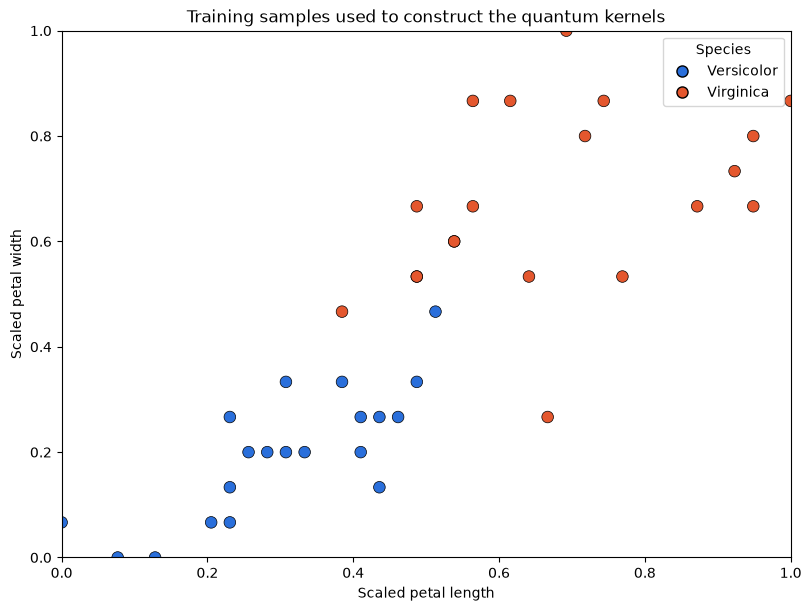

In [17]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.scatterplot(x=X_kernel_train[:, 0], y=X_kernel_train[:, 1], hue=y_kernel_train, palette=CLASS_COLORS, edgecolor="black", linewidth=0.5, s=70, legend=False, ax=ax)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=CLASS_COLORS[0], markeredgecolor="black", markersize=8, label="Versicolor"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=CLASS_COLORS[1], markeredgecolor="black", markersize=8, label="Virginica"),
]

ax.legend(handles=legend_handles, title="Species")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("Scaled petal length")
ax.set_ylabel("Scaled petal width")
ax.set_title("Training samples used to construct the quantum kernels")

plt.show()

# A bad encoding: applying $R_Z$ to $|0\rangle$

Consider

$$
|\phi_{\mathrm{bad}}(x)\rangle
=
R_Z(2\pi x)|0\rangle.
$$

Since

$$
R_Z(\theta)
=
\begin{pmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}
\end{pmatrix},
$$

we obtain

$$
|\phi_{\mathrm{bad}}(x)\rangle
=
e^{-i\pi x}|0\rangle.
$$

The input changes only the global phase. The physical state is independent of $x$,

$$
\rho_{\mathrm{bad}}(x)=|0\rangle\langle 0|.
$$

For two features,

$$
|\phi_{\mathrm{bad}}(x_1,x_2)\rangle
=
e^{-i\pi(x_1+x_2)}|00\rangle.
$$

Therefore,

$$
K_{\mathrm{bad}}(x,z)=1
$$

for every pair of inputs.

This is a valid positive-semidefinite kernel, but it contains no information about the data.

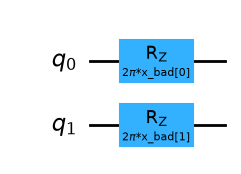

In [18]:
bad_features = ParameterVector("x_bad", 2)

bad_encoding = QuantumCircuit(2, name="Bad RZ encoding")
bad_encoding.rz(2.0 * np.pi * bad_features[0], 0)
bad_encoding.rz(2.0 * np.pi * bad_features[1], 1)

display(bad_encoding.draw(output="mpl", fold=-1))

# A useful comparison: $R_Y$ angle encoding

Consider

$$
|\phi_{\mathrm{angle}}(x)\rangle
=
R_Y(\pi x)|0\rangle.
$$

Since

$$
R_Y(\theta)|0\rangle
=
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
\sin\left(\frac{\theta}{2}\right)|1\rangle,
$$

the encoded state is

$$
|\phi_{\mathrm{angle}}(x)\rangle
=
\cos\left(\frac{\pi x}{2}\right)|0\rangle
+
\sin\left(\frac{\pi x}{2}\right)|1\rangle.
$$

For two inputs $x$ and $z$,

$$
\begin{aligned}
\langle\phi_{\mathrm{angle}}(x)|\phi_{\mathrm{angle}}(z)\rangle
&=
\cos\left(\frac{\pi x}{2}\right)
\cos\left(\frac{\pi z}{2}\right)
+
\sin\left(\frac{\pi x}{2}\right)
\sin\left(\frac{\pi z}{2}\right) \\
&=
\cos\left(\frac{\pi(x-z)}{2}\right).
\end{aligned}
$$

The one-dimensional fidelity kernel is

$$
K_{\mathrm{angle}}(x,z)
=
\cos^2\left(\frac{\pi(x-z)}{2}\right).
$$

With two independently encoded features,

$$
K_{\mathrm{angle}}(x,z)
=
\prod_{j=1}^{2}
\cos^2\left(\frac{\pi(x_j-z_j)}{2}\right).
$$

Unlike the bad encoding, this kernel changes when the input changes.

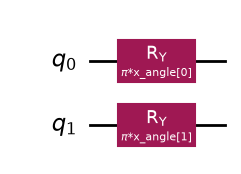

In [19]:
angle_features = ParameterVector("x_angle", 2)

angle_encoding = QuantumCircuit(2, name="Angle encoding")
angle_encoding.ry(np.pi * angle_features[0], 0)
angle_encoding.ry(np.pi * angle_features[1], 1)

display(angle_encoding.draw(output="mpl", fold=-1))

In [20]:
demo_x = np.array([0.20, 0.30])
demo_z = np.array([0.80, 0.70])

bad_x_parameters = dict(zip(bad_features, demo_x))
bad_z_parameters = dict(zip(bad_features, demo_z))
angle_x_parameters = dict(zip(angle_features, demo_x))
angle_z_parameters = dict(zip(angle_features, demo_z))

bad_x_state = Statevector.from_instruction(bad_encoding.assign_parameters(bad_x_parameters))
bad_z_state = Statevector.from_instruction(bad_encoding.assign_parameters(bad_z_parameters))
angle_x_state = Statevector.from_instruction(angle_encoding.assign_parameters(angle_x_parameters))
angle_z_state = Statevector.from_instruction(angle_encoding.assign_parameters(angle_z_parameters))

In [23]:
bad_fidelity = np.abs(np.vdot(bad_x_state.data, bad_z_state.data)) ** 2
angle_analytic_fidelity = np.prod(np.cos(0.5 * np.pi * (demo_x - demo_z)) ** 2)

print("First input:", demo_x)
print("Second input:", demo_z)

print("\nBad encoding state for the first input:")
print(np.round(bad_x_state.data, decimals=4))

print("\nBad encoding state for the second input:")
print(np.round(bad_z_state.data, decimals=4))

print("\nAngle encoding state for the first input:")
print(np.round(angle_x_state.data, decimals=4))

print("\nAngle encoding state for the second input:")
print(np.round(angle_z_state.data, decimals=4))

print("\nBad-kernel fidelity:", bad_fidelity)
print("Angle-kernel fidelity from the analytic formula:", angle_analytic_fidelity)

First input: [0.2 0.3]
Second input: [0.8 0.7]

Bad encoding state for the first input:
[0.-1.j 0.+0.j 0.+0.j 0.+0.j]

Bad encoding state for the second input:
[-0.+1.j  0.+0.j  0.+0.j  0.+0.j]

Angle encoding state for the first input:
[0.8474+0.j 0.2753+0.j 0.4318+0.j 0.1403+0.j]

Angle encoding state for the second input:
[0.1403+0.j 0.4318+0.j 0.2753+0.j 0.8474+0.j]

Bad-kernel fidelity: 0.9999999999999998
Angle-kernel fidelity from the analytic formula: 0.22612712429686835


The bad statevectors may contain different complex phases, but their fidelity is one because they differ only by a global phase.

The angle encoding changes the relative amplitudes of computational-basis states. Different inputs therefore produce physically different quantum states.

A quantum kernel responds to physical differences between states. It cannot extract information from an unobservable global phase.

## The induced Gram matrices

In [25]:
bad_quantum_kernel = FidelityStatevectorKernel(feature_map=bad_encoding)
angle_quantum_kernel = FidelityStatevectorKernel(feature_map=angle_encoding)

bad_training_kernel_matrix = bad_quantum_kernel.evaluate(X_kernel_train)
angle_training_kernel_matrix = angle_quantum_kernel.evaluate(X_kernel_train)

print("Bad kernel minimum:", bad_training_kernel_matrix.min())
print("Bad kernel maximum:", bad_training_kernel_matrix.max())
print("Bad kernel rank:", np.linalg.matrix_rank(bad_training_kernel_matrix, tol=1e-10))
print("Angle kernel rank:", np.linalg.matrix_rank(angle_training_kernel_matrix, tol=1e-10))

Bad kernel minimum: 0.9999999999999993
Bad kernel maximum: 1.0000000000000009
Bad kernel rank: 1
Angle kernel rank: 9


In [26]:
number_of_training_samples = len(X_kernel_train)
centering_matrix = np.eye(number_of_training_samples) - np.ones((number_of_training_samples, number_of_training_samples)) / number_of_training_samples

bad_centered_kernel = centering_matrix @ bad_training_kernel_matrix @ centering_matrix
angle_centered_kernel = centering_matrix @ angle_training_kernel_matrix @ centering_matrix

print("Norm of the centered bad kernel:", np.linalg.norm(bad_centered_kernel))
print("Norm of the centered angle kernel:", np.linalg.norm(angle_centered_kernel))

Norm of the centered bad kernel: 8.177808016225405e-15
Norm of the centered angle kernel: 11.050458538807108


The bad Gram matrix is

$$
K_{\mathrm{bad}}
=
\begin{pmatrix}
1 & 1 & \cdots & 1 \\
1 & 1 & \cdots & 1 \\
\vdots & \vdots & \ddots & \vdots \\
1 & 1 & \cdots & 1
\end{pmatrix}.
$$

It has rank one.

Let

$$
H
=
I-\frac{1}{m}\mathbf{1}\mathbf{1}^{\mathsf{T}}
$$

be the centering matrix. Then

$$
HK_{\mathrm{bad}}H=0.
$$

The encoded data has no variation around its mean in feature space. Every sample occupies the same feature-space location.

# The classifier does not infer the kernel

Write the binary labels as $\widetilde{y}_i\in\{-1,+1\}$. Once a kernel has been supplied, the SVM solves

$$
\begin{aligned}
\max_{\alpha\in\mathbb{R}^m}
\quad &
\sum_{i=1}^{m}\alpha_i
-
\frac{1}{2}
\sum_{i,j=1}^{m}
\alpha_i\alpha_j
\widetilde{y}_i\widetilde{y}_j
K(x_i,x_j) \\
\text{subject to}
\quad &
0\leq\alpha_i\leq C, \\
&
\sum_{i=1}^{m}\alpha_i\widetilde{y}_i=0.
\end{aligned}
$$

The resulting decision function is

$$
f(x)
=
\sum_{i=1}^{m}
\alpha_i\widetilde{y}_iK(x_i,x)+b.
$$

The SVM learns $\alpha$ and $b$. It does not learn the formula for $K$.

For the constant bad kernel,

$$
K_{\mathrm{bad}}(x_i,x)=1.
$$

Therefore,

$$
\begin{aligned}
f_{\mathrm{bad}}(x)
&=
\sum_{i=1}^{m}\alpha_i\widetilde{y}_i+b \\
&=
b,
\end{aligned}
$$

because the SVM constraint requires

$$
\sum_{i=1}^{m}\alpha_i\widetilde{y}_i=0.
$$

The prediction is independent of $x$. No optimization of the SVM coefficients can repair the collapsed encoding.

In [27]:
bad_test_kernel_matrix = bad_quantum_kernel.evaluate(X_test_unit, X_kernel_train)
angle_test_kernel_matrix = angle_quantum_kernel.evaluate(X_test_unit, X_kernel_train)

bad_precomputed_classifier = SVC(kernel="precomputed", C=SVC_C)
angle_precomputed_classifier = SVC(kernel="precomputed", C=SVC_C)

bad_precomputed_classifier.fit(bad_training_kernel_matrix, y_kernel_train)
angle_precomputed_classifier.fit(angle_training_kernel_matrix, y_kernel_train)

bad_test_predictions = bad_precomputed_classifier.predict(bad_test_kernel_matrix)
angle_test_predictions = angle_precomputed_classifier.predict(angle_test_kernel_matrix)

fixed_kernel_performance = pd.DataFrame({
    "Encoding": ["Bad RZ encoding", "Angle RY encoding"],
    "Kernel rank": [
        np.linalg.matrix_rank(bad_training_kernel_matrix, tol=1e-10),
        np.linalg.matrix_rank(angle_training_kernel_matrix, tol=1e-10),
    ],
    "Test accuracy": [
        accuracy_score(y_test, bad_test_predictions),
        accuracy_score(y_test, angle_test_predictions),
    ],
})

display(fixed_kernel_performance)

,Encoding,Kernel rank,Test accuracy
0,Bad RZ encoding,1,0.56
1,Angle RY encoding,9,0.96


The SVM objects above never receive a circuit or a quantum state.

They receive:

- an $m\times m$ training Gram matrix;
- an $n_{\mathrm{test}}\times m$ test-versus-training matrix.

The quantum-kernel object evaluates encoded-state fidelities and constructs these matrices. The SVM treats them as ordinary numerical inputs.

This separates the two jobs:

$$
U_\phi
\longrightarrow
K_\phi
\longrightarrow
\text{SVM}.
$$

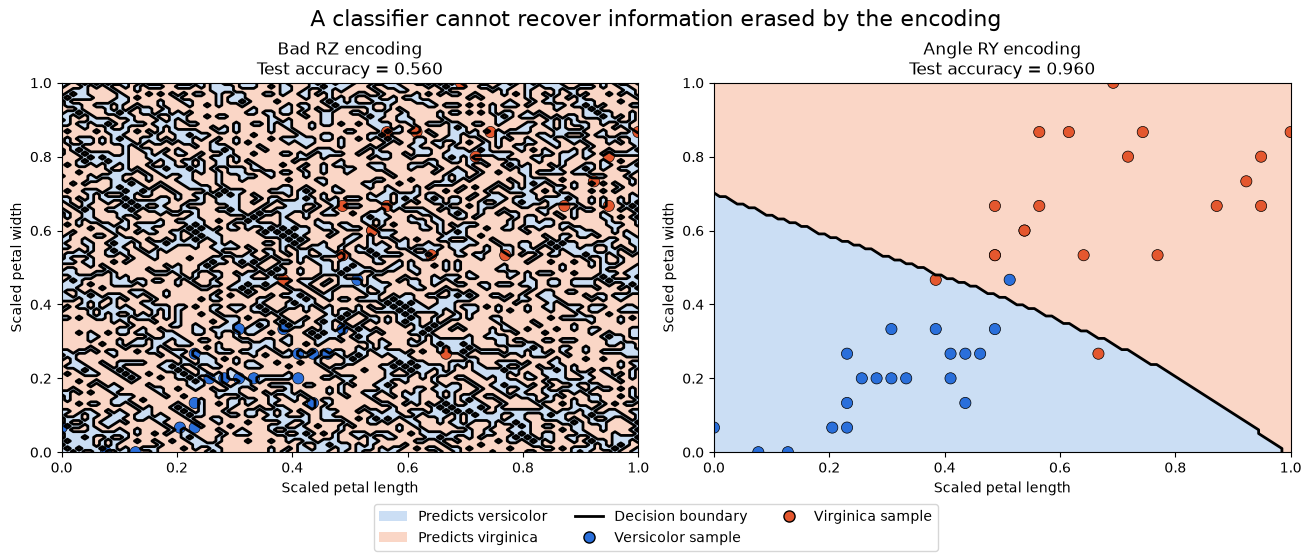

In [28]:
grid_coordinates = np.linspace(0.0, 1.0, 100)
grid_petal_length, grid_petal_width = np.meshgrid(grid_coordinates, grid_coordinates)
grid_points = np.column_stack([grid_petal_length.ravel(), grid_petal_width.ravel()])

bad_grid_kernel = bad_quantum_kernel.evaluate(grid_points, X_kernel_train)
angle_grid_kernel = angle_quantum_kernel.evaluate(grid_points, X_kernel_train)

bad_grid_predictions = bad_precomputed_classifier.predict(bad_grid_kernel).reshape(grid_petal_length.shape)
angle_grid_predictions = angle_precomputed_classifier.predict(angle_grid_kernel).reshape(grid_petal_length.shape)

decision_regions = {
    "Bad RZ encoding": (bad_grid_predictions, fixed_kernel_performance.loc[0, "Test accuracy"]),
    "Angle RY encoding": (angle_grid_predictions, fixed_kernel_performance.loc[1, "Test accuracy"]),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

for ax, (model_name, model_information) in zip(axes, decision_regions.items()):
    grid_predictions, test_accuracy = model_information

    ax.contourf(grid_petal_length, grid_petal_width, grid_predictions, levels=[-0.5, 0.5, 1.5], colors=["#8CB7E8", "#F4A582"], alpha=0.45)

    if np.unique(grid_predictions).size > 1:
        ax.contour(grid_petal_length, grid_petal_width, grid_predictions, levels=[0.5], colors="black", linewidths=2.0)

    sns.scatterplot(x=X_kernel_train[:, 0], y=X_kernel_train[:, 1], hue=y_kernel_train, palette=CLASS_COLORS, edgecolor="black", linewidth=0.5, s=65, legend=False, ax=ax)

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Scaled petal length")
    ax.set_ylabel("Scaled petal width")
    ax.set_title(f"{model_name}\nTest accuracy = {test_accuracy:.3f}")

legend_handles = [
    Patch(facecolor="#8CB7E8", alpha=0.45, label="Predicts versicolor"),
    Patch(facecolor="#F4A582", alpha=0.45, label="Predicts virginica"),
    Line2D([0], [0], color="black", linewidth=2.0, label="Decision boundary"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=CLASS_COLORS[0], markeredgecolor="black", markersize=8, label="Versicolor sample"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=CLASS_COLORS[1], markeredgecolor="black", markersize=8, label="Virginica sample"),
]

fig.legend(handles=legend_handles, loc="outside lower center", ncol=3, frameon=True)
fig.suptitle("A classifier cannot recover information erased by the encoding", fontsize=16)

plt.show()

# Kernel choice is model design

There is no unique kernel associated with a classical dataset.

A kernel is proposed using assumptions about which similarities should matter.

| Assumption | Possible encoding |
|---|---|
| Nearby values should produce similar states | Smooth angle encoding |
| Features are periodic | Phase encoding |
| Discrete categories are important | Basis encoding |
| Relative vector direction is important | Amplitude encoding |
| Joint feature values are important | $ZZ$ or another interacting encoding |

These choices are inductive biases.

After proposing several candidates, validation data can be used to select among them. This is model selection, not kernel discovery from nothing.

In [29]:
X_kernel_fit, X_kernel_validation, y_kernel_fit, y_kernel_validation = train_test_split(X_kernel_train, y_kernel_train, test_size=0.25, stratify=y_kernel_train, random_state=SEED)

print("Kernel-fitting samples:", len(X_kernel_fit))
print("Validation samples:", len(X_kernel_validation))

Kernel-fitting samples: 30
Validation samples: 10


In [30]:
candidate_kernels = {
    "Bad RZ encoding": bad_quantum_kernel,
    "Angle RY encoding": angle_quantum_kernel,
}

candidate_validation_rows = []

for kernel_name, quantum_kernel in candidate_kernels.items():
    fitting_kernel_matrix = quantum_kernel.evaluate(X_kernel_fit)
    validation_kernel_matrix = quantum_kernel.evaluate(X_kernel_validation, X_kernel_fit)

    candidate_classifier = SVC(kernel="precomputed", C=SVC_C)
    candidate_classifier.fit(fitting_kernel_matrix, y_kernel_fit)

    validation_predictions = candidate_classifier.predict(validation_kernel_matrix)
    validation_accuracy = accuracy_score(y_kernel_validation, validation_predictions)

    candidate_validation_rows.append({
        "Candidate kernel": kernel_name,
        "Validation accuracy": validation_accuracy,
    })

candidate_validation_results = pd.DataFrame(candidate_validation_rows)
candidate_validation_results = candidate_validation_results.sort_values("Validation accuracy", ascending=False).reset_index(drop=True)

display(candidate_validation_results)

selected_kernel_name = candidate_validation_results.loc[0, "Candidate kernel"]
print("Selected candidate:", selected_kernel_name)

,Candidate kernel,Validation accuracy
0,Angle RY encoding,0.9
1,Bad RZ encoding,0.5


Selected candidate: Angle RY encoding


The preceding code did not discover the angle-kernel formula.

We explicitly supplied two candidate circuits. Validation answered only:

> Which supplied kernel generalizes better to the validation samples?

If every proposed encoding is inappropriate, validation can only select the least bad candidate.

# Learning within a kernel family

Suppose the encoding contains trainable parameters,

$$
|\phi_\theta(x)\rangle
=
U_\phi(x;\theta)|0\rangle^{\otimes n}.
$$

It defines the kernel family

$$
\mathcal{K}_\phi
=
\left\{
K_\theta:
K_\theta(x,z)
=
\left|
\langle\phi_\theta(x)|\phi_\theta(z)\rangle
\right|^2,
\ \theta\in\Theta
\right\}.
$$

Kernel learning selects $\theta$. It does not change the architecture $U_\phi$.

## Trainable angle encoding

We first use

$$
U_{\mathrm{angle}}(x;\theta)
=
R_Y(\pi\theta_1x_1)
\otimes
R_Y(\pi\theta_2x_2).
$$

Its kernel is

$$
K_{\mathrm{angle},\theta}(x,z)
=
\prod_{j=1}^{2}
\cos^2\left(
\frac{\pi\theta_j(x_j-z_j)}{2}
\right).
$$

Each $\theta_j$ controls the resolution along one feature. The kernel nevertheless remains a product of one-dimensional similarities.

Training can change the feature scales, but it cannot introduce an interaction between the features.

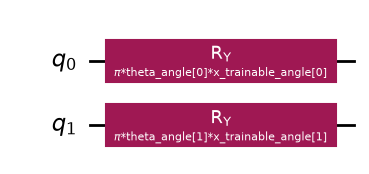

Data parameters: [ParameterVectorElement(x_trainable_angle[0]), ParameterVectorElement(x_trainable_angle[1])]
Trainable parameters: [ParameterVectorElement(theta_angle[0]), ParameterVectorElement(theta_angle[1])]


In [31]:
trainable_angle_features = ParameterVector("x_trainable_angle", 2)
angle_weights = ParameterVector("theta_angle", 2)

trainable_angle_encoding = QuantumCircuit(2, name="Trainable angle")
trainable_angle_encoding.ry(np.pi * angle_weights[0] * trainable_angle_features[0], 0)
trainable_angle_encoding.ry(np.pi * angle_weights[1] * trainable_angle_features[1], 1)

display(trainable_angle_encoding.draw(output="mpl", fold=-1))

print("Data parameters:", list(trainable_angle_features))
print("Trainable parameters:", list(angle_weights))

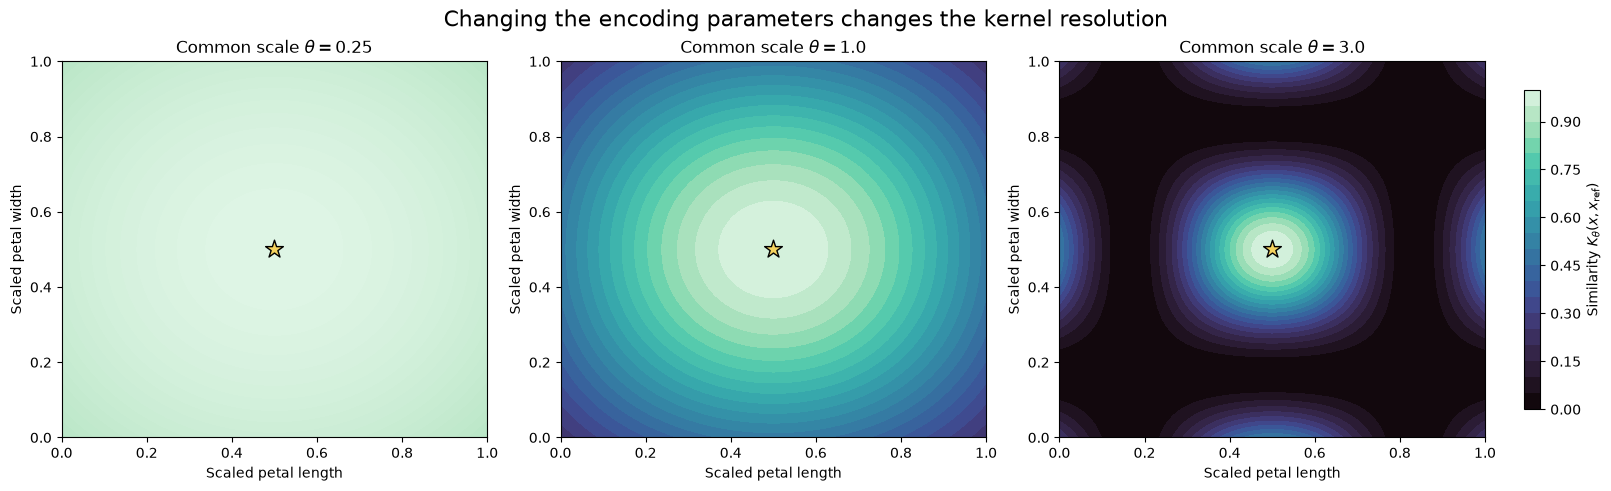

In [32]:
reference_point = np.array([0.5, 0.5])
similarity_coordinates = np.linspace(0.0, 1.0, 120)
similarity_petal_length, similarity_petal_width = np.meshgrid(similarity_coordinates, similarity_coordinates)
similarity_grid = np.column_stack([similarity_petal_length.ravel(), similarity_petal_width.ravel()])

angle_scales = [0.25, 1.0, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, angle_scale_value in zip(axes, angle_scales):
    coordinate_differences = similarity_grid - reference_point
    similarities = np.prod(np.cos(0.5 * np.pi * angle_scale_value * coordinate_differences) ** 2, axis=1)
    similarity_surface = similarities.reshape(similarity_petal_length.shape)

    contour = ax.contourf(similarity_petal_length, similarity_petal_width, similarity_surface, levels=20, vmin=0.0, vmax=1.0, cmap="mako")
    ax.scatter(reference_point[0], reference_point[1], marker="*", color="#F4D35E", edgecolor="black", s=180)
    ax.set_xlabel("Scaled petal length")
    ax.set_ylabel("Scaled petal width")
    ax.set_title(rf"Common scale $\theta={angle_scale_value}$")

colorbar = fig.colorbar(contour, ax=axes, shrink=0.85, pad=0.02)
colorbar.set_label(r"Similarity $K_\theta(x,x_{\mathrm{ref}})$")

fig.suptitle("Changing the encoding parameters changes the kernel resolution", fontsize=16)

plt.show()

Small values of $\theta$ map most inputs to nearby states. The resulting kernel is broad and may fail to resolve class differences.

Larger values produce more rapidly changing similarities. If the scale becomes too large, the trigonometric encoding produces repeated similarity patterns.

The parameters change the kernel bandwidth, but the product structure remains unchanged.

## Trainable $ZZ$ encoding

We now introduce a data-dependent interaction,

$$
U_{ZZ}(x;\theta)
=
R_{ZZ}(\pi\theta_3x_1x_2)
\left[
P(\pi\theta_1x_1)
\otimes
P(\pi\theta_2x_2)
\right]
(H\otimes H).
$$

The first two parameters control the local feature phases. The third parameter controls the interaction phase.

Because the circuit contains the joint quantity $x_1x_2$, its kernel does not generally factor into two independent one-dimensional kernels.

# The exact interdependence

For each encoding parameter vector $\theta$, the SVM obtains different optimal coefficients,

$$
\alpha^\star(\theta)
=
\operatorname*{arg\,max}_{\alpha\in\mathcal{A}}
\left[
\sum_i\alpha_i
-
\frac{1}{2}
\sum_{i,j}
\alpha_i\alpha_j
\widetilde{y}_i\widetilde{y}_j
K_\theta(x_i,x_j)
\right].
$$

The kernel trainer then evaluates the current encoding parameters using a classifier-dependent loss,

$$
\theta^\star
=
\operatorname*{arg\,min}_{\theta\in\Theta}
\mathcal{L}_{\mathrm{kernel}}
\left(
K_\theta,
\alpha^\star(\theta),
y
\right).
$$

The dependence is cyclic:

$$
\theta
\longrightarrow
K_\theta
\longrightarrow
\alpha^\star(\theta)
\longrightarrow
\mathcal{L}_{\mathrm{kernel}}
\longrightarrow
\theta.
$$

The circuit architecture remains fixed throughout this loop.

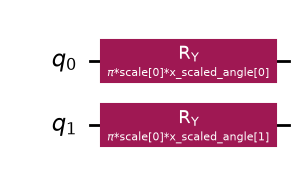

In [33]:
scaled_angle_features = ParameterVector("x_scaled_angle", 2)
common_angle_scale = ParameterVector("scale", 1)

scaled_angle_encoding = QuantumCircuit(2, name="Scaled angle")
scaled_angle_encoding.ry(np.pi * common_angle_scale[0] * scaled_angle_features[0], 0)
scaled_angle_encoding.ry(np.pi * common_angle_scale[0] * scaled_angle_features[1], 1)

scaled_angle_kernel = TrainableFidelityStatevectorKernel(feature_map=scaled_angle_encoding, training_parameters=common_angle_scale, shots=None)

display(scaled_angle_encoding.draw(output="mpl", fold=-1))

In [34]:
kernel_scale_values = np.linspace(0.05, 4.0, 40)
svc_kernel_loss = SVCLoss(C=SVC_C)

kernel_loss_values = []
validation_accuracy_values = []

for scale_value in tqdm(kernel_scale_values, desc="Scanning angle-kernel scale"):
    current_parameter = np.array([scale_value])

    current_loss = svc_kernel_loss.evaluate(current_parameter, scaled_angle_kernel, X_kernel_fit, y_kernel_fit)
    kernel_loss_values.append(current_loss)

    scaled_angle_kernel.assign_training_parameters(current_parameter)
    fitting_kernel_matrix = scaled_angle_kernel.evaluate(X_kernel_fit)
    validation_kernel_matrix = scaled_angle_kernel.evaluate(X_kernel_validation, X_kernel_fit)

    current_classifier = SVC(kernel="precomputed", C=SVC_C)
    current_classifier.fit(fitting_kernel_matrix, y_kernel_fit)

    validation_predictions = current_classifier.predict(validation_kernel_matrix)
    validation_accuracy_values.append(accuracy_score(y_kernel_validation, validation_predictions))

Scanning angle-kernel scale:   0%|          | 0/40 [00:00<?, ?it/s]

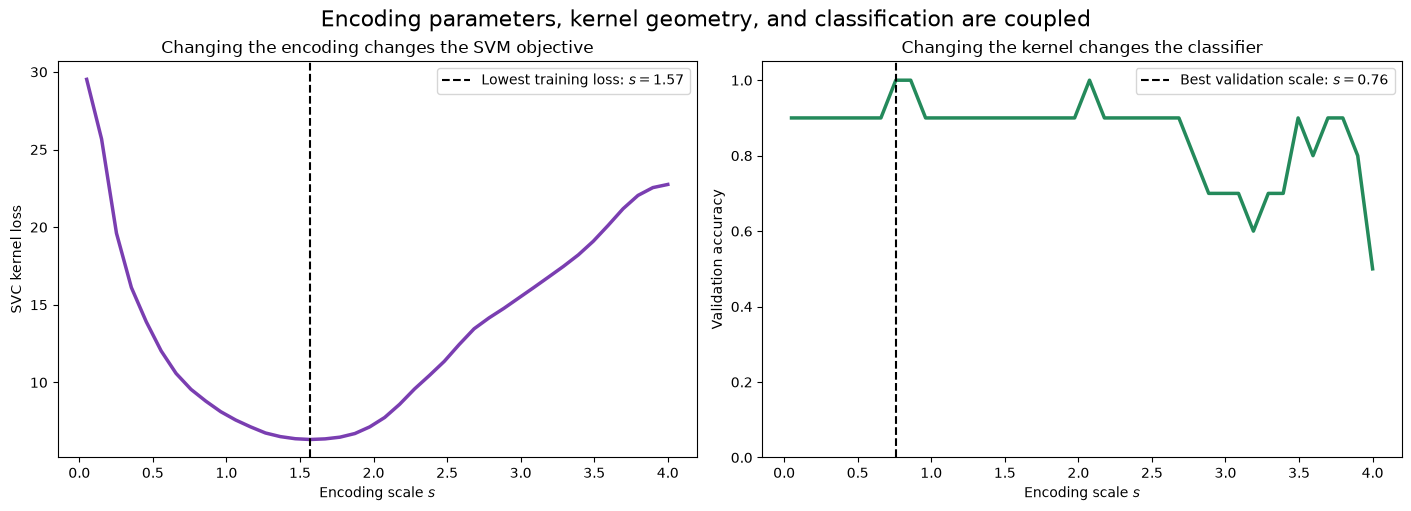

In [35]:
lowest_loss_scale = kernel_scale_values[np.argmin(kernel_loss_values)]
best_validation_scale = kernel_scale_values[np.argmax(validation_accuracy_values)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(kernel_scale_values, kernel_loss_values, color="#7A3EB1", linewidth=2.5)
axes[0].axvline(lowest_loss_scale, color="black", linestyle="--", label=rf"Lowest training loss: $s={lowest_loss_scale:.2f}$")
axes[0].set_xlabel(r"Encoding scale $s$")
axes[0].set_ylabel("SVC kernel loss")
axes[0].set_title("Changing the encoding changes the SVM objective")
axes[0].legend()

axes[1].plot(kernel_scale_values, validation_accuracy_values, color="#248A5B", linewidth=2.5)
axes[1].axvline(best_validation_scale, color="black", linestyle="--", label=rf"Best validation scale: $s={best_validation_scale:.2f}$")
axes[1].set_ylim(0.0, 1.05)
axes[1].set_xlabel(r"Encoding scale $s$")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Changing the kernel changes the classifier")
axes[1].legend()

fig.suptitle("Encoding parameters, kernel geometry, and classification are coupled", fontsize=16)

plt.show()

# Label-dependent quantum-kernel training

Qiskit's `SVCLoss` constructs the kernel matrix for the current parameters and fits an SVM.

Its kernel-training objective is

$$
\mathcal{L}_{\mathrm{SVC}}(\theta)
=
\sum_i\alpha_i
-
\frac{1}{2}
\sum_{i,j}
\alpha_i\alpha_j
\widetilde{y}_i\widetilde{y}_j
K_\theta(x_i,x_j),
$$

where the SVM coefficients depend on the current kernel.

We use COBYLA to minimize this objective without introducing gradient calculations.

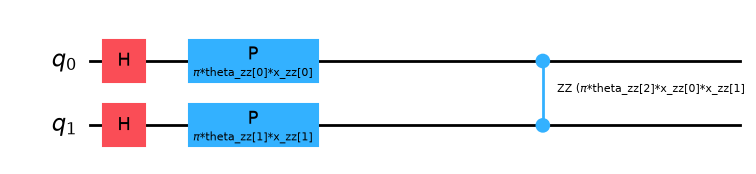

In [37]:
zz_features = ParameterVector("x_zz", 2)
zz_weights = ParameterVector("theta_zz", 3)

trainable_zz_encoding = QuantumCircuit(2, name="Trainable ZZ encoding")

# Create a superposition so that the phase operations affect relative phases.
trainable_zz_encoding.h([0, 1])

# Encode each Iris feature using a trainable single-qubit phase scale.
trainable_zz_encoding.p(np.pi * zz_weights[0] * zz_features[0], 0)
trainable_zz_encoding.p(np.pi * zz_weights[1] * zz_features[1], 1)

# Encode the product of the two features using a trainable ZZ interaction.
trainable_zz_encoding.rzz(np.pi * zz_weights[2] * zz_features[0] * zz_features[1], 0, 1)

trainable_zz_encoding.draw("mpl")

In [38]:
angle_initial_point = np.ones(len(angle_weights))
zz_initial_point = np.ones(len(zz_weights))

angle_fixed_kernel = TrainableFidelityStatevectorKernel(feature_map=trainable_angle_encoding, training_parameters=angle_weights, shots=None)
angle_fixed_kernel.assign_training_parameters(angle_initial_point)

zz_fixed_kernel = TrainableFidelityStatevectorKernel(feature_map=trainable_zz_encoding, training_parameters=zz_weights, shots=None)
zz_fixed_kernel.assign_training_parameters(zz_initial_point)

angle_kernel_for_training = TrainableFidelityStatevectorKernel(feature_map=trainable_angle_encoding, training_parameters=angle_weights, shots=None)
zz_kernel_for_training = TrainableFidelityStatevectorKernel(feature_map=trainable_zz_encoding, training_parameters=zz_weights, shots=None)

angle_initial_matrix = angle_fixed_kernel.evaluate(X_kernel_train)
zz_initial_matrix = zz_fixed_kernel.evaluate(X_kernel_train)

In [39]:
kernel_training_loss = SVCLoss(C=SVC_C)

angle_initial_loss = kernel_training_loss.evaluate(angle_initial_point, angle_fixed_kernel, X_kernel_train, y_kernel_train)
zz_initial_loss = kernel_training_loss.evaluate(zz_initial_point, zz_fixed_kernel, X_kernel_train, y_kernel_train)

print("Initial angle-kernel loss:", angle_initial_loss)
print("Initial ZZ-kernel loss:", zz_initial_loss)

Initial angle-kernel loss: 9.248189763890778
Initial ZZ-kernel loss: 10.081956046914032


In [40]:
training_progress = tqdm(total=2, desc="Training quantum kernels", unit="kernel")

angle_optimizer = COBYLA(maxiter=KERNEL_TRAINING_MAXITER)
angle_trainer = QuantumKernelTrainer(quantum_kernel=angle_kernel_for_training, loss=kernel_training_loss, optimizer=angle_optimizer, initial_point=angle_initial_point)

angle_start_time = perf_counter()
angle_training_result = angle_trainer.fit(X_kernel_train, y_kernel_train)
angle_training_time = perf_counter() - angle_start_time

training_progress.set_postfix(kernel="Angle")
training_progress.update(1)

zz_optimizer = COBYLA(maxiter=KERNEL_TRAINING_MAXITER)
zz_trainer = QuantumKernelTrainer(quantum_kernel=zz_kernel_for_training, loss=kernel_training_loss, optimizer=zz_optimizer, initial_point=zz_initial_point)

zz_start_time = perf_counter()
zz_training_result = zz_trainer.fit(X_kernel_train, y_kernel_train)
zz_training_time = perf_counter() - zz_start_time

training_progress.set_postfix(kernel="ZZ")
training_progress.update(1)
training_progress.close()

angle_trained_kernel = angle_training_result.quantum_kernel
zz_trained_kernel = zz_training_result.quantum_kernel

Training quantum kernels:   0%|          | 0/2 [00:00<?, ?kernel/s]

In [41]:
angle_parameter_table = pd.DataFrame({
    "Encoding": "Angle",
    "Parameter": [str(parameter) for parameter in angle_weights],
    "Initial value": angle_initial_point,
    "Learned value": angle_training_result.optimal_point,
})

zz_parameter_table = pd.DataFrame({
    "Encoding": "ZZ",
    "Parameter": [str(parameter) for parameter in zz_weights],
    "Initial value": zz_initial_point,
    "Learned value": zz_training_result.optimal_point,
})

learned_parameter_table = pd.concat([angle_parameter_table, zz_parameter_table], ignore_index=True)

training_summary = pd.DataFrame({
    "Encoding": ["Angle", "ZZ"],
    "Initial loss": [angle_initial_loss, zz_initial_loss],
    "Final loss": [angle_training_result.optimal_value, zz_training_result.optimal_value],
    "Optimizer evaluations": [angle_training_result.optimizer_evals, zz_training_result.optimizer_evals],
    "Training time in seconds": [angle_training_time, zz_training_time],
})

display(learned_parameter_table)
display(training_summary)

,Encoding,Parameter,Initial value,Learned value
0,Angle,theta_angle[0],1.0,1.373423
1,Angle,theta_angle[1],1.0,1.858004
2,ZZ,theta_zz[0],1.0,1.377551
3,ZZ,theta_zz[1],1.0,1.868173
4,ZZ,theta_zz[2],1.0,0.064813


,Encoding,Initial loss,Final loss,Optimizer evaluations,Training time in seconds
0,Angle,9.248190,7.228814,30,0.162119
1,ZZ,10.081956,7.232134,30,0.166071


In [42]:
angle_trained_matrix = angle_trained_kernel.evaluate(X_kernel_train)
zz_trained_matrix = zz_trained_kernel.evaluate(X_kernel_train)

## A descriptive class-similarity diagnostic

The idealized class-similarity matrix assigns

$$
K_{\mathrm{target}}(x_i,x_j)
=
\begin{cases}
1, & y_i=y_j, \\
0, & y_i\neq y_j.
\end{cases}
$$

We compare its off-diagonal entries with the quantum kernel.

The diagonal is excluded because every fidelity kernel automatically satisfies

$$
K_\theta(x_i,x_i)=1.
$$

Including those guaranteed entries would artificially increase the apparent agreement.

In [43]:
same_class_target = (y_kernel_train[:, None] == y_kernel_train[None, :]).astype(float)
off_diagonal_mask = ~np.eye(len(y_kernel_train), dtype=bool)

angle_initial_alignment = cosine_similarity(angle_initial_matrix[off_diagonal_mask].reshape(1, -1), same_class_target[off_diagonal_mask].reshape(1, -1))[0, 0]
angle_trained_alignment = cosine_similarity(angle_trained_matrix[off_diagonal_mask].reshape(1, -1), same_class_target[off_diagonal_mask].reshape(1, -1))[0, 0]
zz_initial_alignment = cosine_similarity(zz_initial_matrix[off_diagonal_mask].reshape(1, -1), same_class_target[off_diagonal_mask].reshape(1, -1))[0, 0]
zz_trained_alignment = cosine_similarity(zz_trained_matrix[off_diagonal_mask].reshape(1, -1), same_class_target[off_diagonal_mask].reshape(1, -1))[0, 0]

alignment_comparison = pd.DataFrame({
    "Encoding": ["Angle", "Angle", "ZZ", "ZZ"],
    "Kernel": ["Initial", "Trained", "Initial", "Trained"],
    "Descriptive class alignment": [angle_initial_alignment, angle_trained_alignment, zz_initial_alignment, zz_trained_alignment],
})

display(alignment_comparison)

,Encoding,Kernel,Descriptive class alignment
0,Angle,Initial,0.838534
1,Angle,Trained,0.828969
2,ZZ,Initial,0.808851
3,ZZ,Trained,0.828227


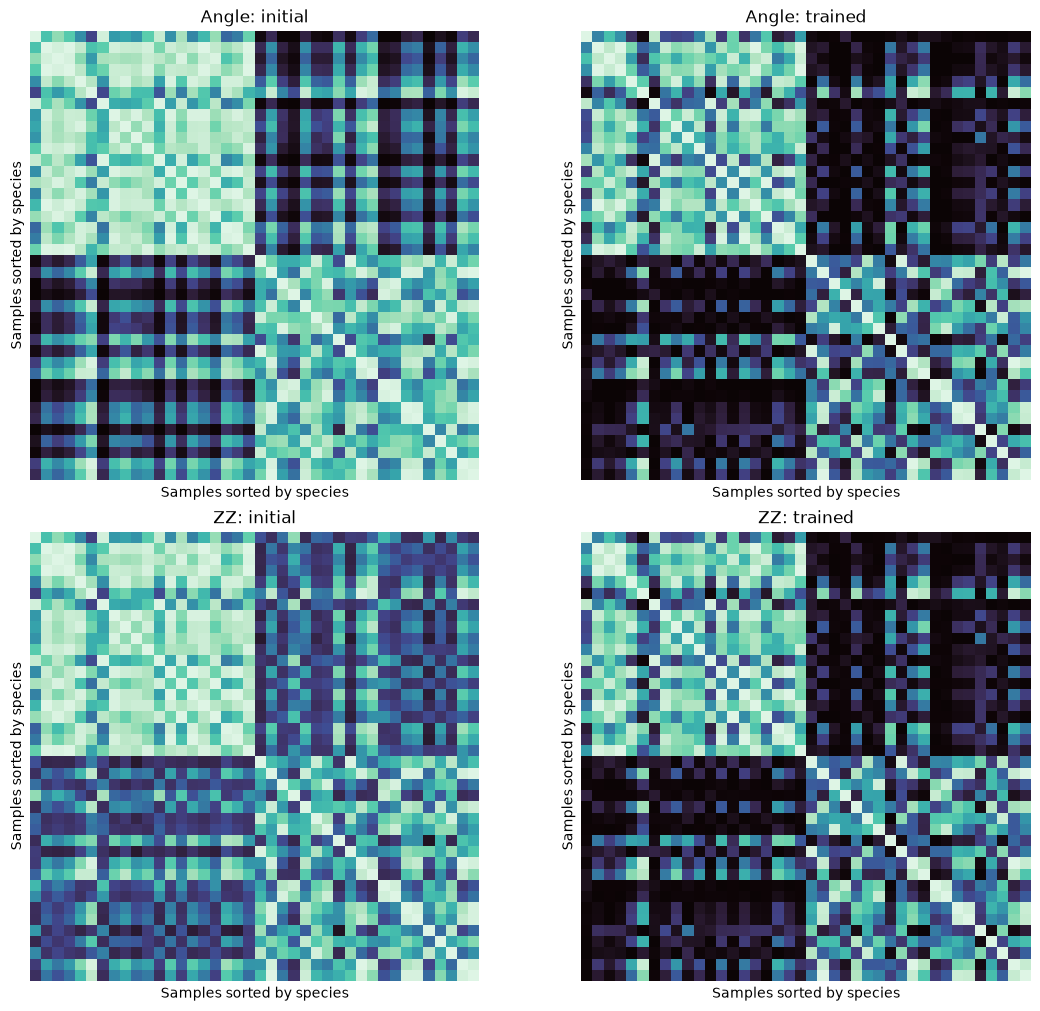

In [45]:
# Sort the training samples by class label so that the two classes form visible blocks.
label_order = np.argsort(y_kernel_train)

fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)
axes = axes.ravel()

for ax, (matrix_name, kernel_matrix) in zip(axes, kernel_matrix_comparison.items()):
    ordered_matrix = kernel_matrix[np.ix_(label_order, label_order)]
    sns.heatmap(ordered_matrix, vmin=0.0, vmax=1.0, cmap="mako", square=True, xticklabels=False, yticklabels=False, cbar=False, ax=ax)
    ax.set_xlabel("Samples sorted by species")
    ax.set_ylabel("Samples sorted by species")
    ax.set_title(matrix_name)

plt.show()

The samples are sorted by species. A strongly class-aligned kernel would show two bright diagonal blocks and darker off-diagonal blocks.

The displayed alignment is only a diagnostic. The optimizer minimizes the SVC kernel loss rather than directly maximizing the plotted cosine similarity.

The angle trainer can only change two feature scales. The $ZZ$ trainer can change two local phases and one interaction phase.

Therefore,

$$
K_{\mathrm{angle},\theta^\star}
\in
\mathcal{K}_{\mathrm{angle}},
\qquad
K_{ZZ,\theta^\star}
\in
\mathcal{K}_{ZZ},
$$

where the two circuit architectures define different kernel families.

In [47]:
classification_models = {
    "Classical RBF": SVC(kernel="rbf", C=SVC_C, gamma="scale"),
    "Bad RZ kernel": QSVC(quantum_kernel=bad_quantum_kernel, C=SVC_C),
    "Fixed angle kernel": QSVC(quantum_kernel=angle_fixed_kernel, C=SVC_C),
    "Learned angle kernel": QSVC(quantum_kernel=angle_trained_kernel, C=SVC_C),
    "Fixed ZZ kernel": QSVC(quantum_kernel=zz_fixed_kernel, C=SVC_C),
    "Learned ZZ kernel": QSVC(quantum_kernel=zz_trained_kernel, C=SVC_C),
}

In [48]:
classification_rows = []
fitted_classification_models = {}

progress_bar = tqdm(classification_models.items(), total=len(classification_models), desc="Fitting classifiers", unit="model")

for model_name, model in progress_bar:
    start_time = perf_counter()
    model.fit(X_kernel_train, y_kernel_train)
    fitting_time = perf_counter() - start_time

    training_predictions = model.predict(X_kernel_train)
    test_predictions = model.predict(X_test_unit)

    fitted_classification_models[model_name] = model

    classification_rows.append({
        "Model": model_name,
        "Training accuracy": accuracy_score(y_kernel_train, training_predictions),
        "Test accuracy": accuracy_score(y_test, test_predictions),
        "Balanced test accuracy": balanced_accuracy_score(y_test, test_predictions),
        "Test F1": f1_score(y_test, test_predictions),
        "Classifier fitting time in seconds": fitting_time,
    })

    progress_bar.set_postfix(model=model_name)

classification_performance = pd.DataFrame(classification_rows)
classification_performance = classification_performance.sort_values("Test accuracy", ascending=False).reset_index(drop=True)

display(classification_performance)

Fitting classifiers:   0%|          | 0/6 [00:00<?, ?model/s]

,Model,Training accuracy,Test accuracy,Balanced test accuracy,Test F1,Classifier fitting time in seconds
0,Classical RBF,0.950,0.96,0.958333,0.962963,0.001288
1,Fixed angle kernel,0.925,0.96,0.958333,0.962963,0.007018
2,Learned angle kernel,0.950,0.96,0.958333,0.962963,0.005556
3,Fixed ZZ kernel,0.900,0.96,0.958333,0.962963,0.006669
4,Learned ZZ kernel,0.950,0.96,0.958333,0.962963,0.006247
5,Bad RZ kernel,0.450,0.56,0.548077,0.666667,0.013707


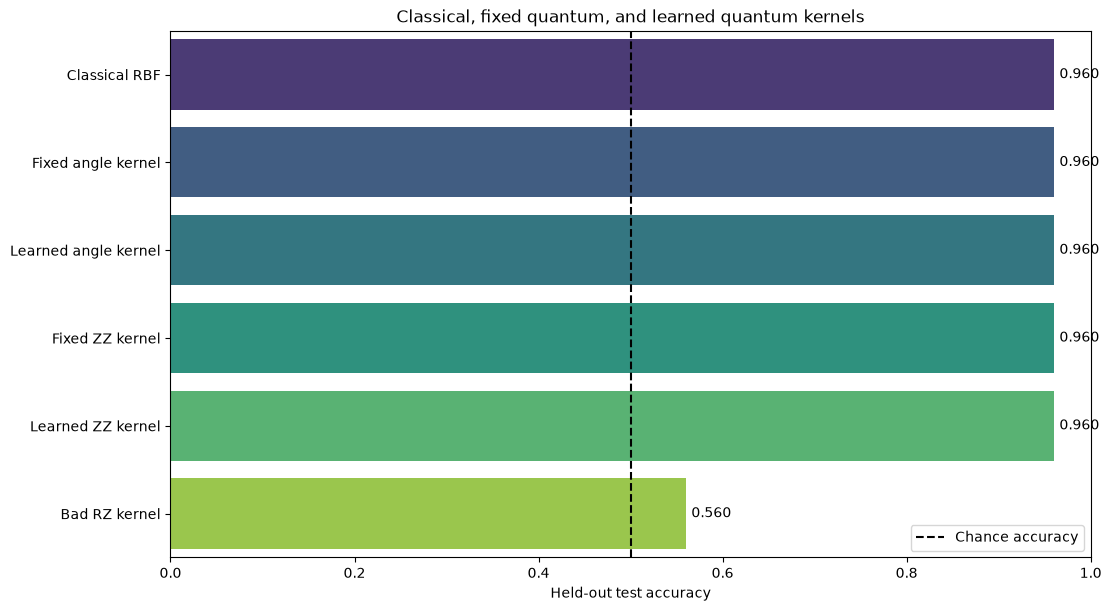

In [49]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

performance_order = classification_performance["Model"]
sns.barplot(data=classification_performance, x="Test accuracy", y="Model", order=performance_order, hue="Model", legend=False, palette="viridis", ax=ax)

ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Chance accuracy")
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("Held-out test accuracy")
ax.set_ylabel("")
ax.set_title("Classical, fixed quantum, and learned quantum kernels")
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4)

plt.show()

In [50]:
decision_grid_coordinates = np.linspace(0.0, 1.0, 70)
decision_petal_length, decision_petal_width = np.meshgrid(decision_grid_coordinates, decision_grid_coordinates)
decision_grid_points = np.column_stack([decision_petal_length.ravel(), decision_petal_width.ravel()])

decision_region_predictions = {}

for model_name, model in tqdm(fitted_classification_models.items(), desc="Evaluating decision regions"):
    grid_predictions = model.predict(decision_grid_points)
    decision_region_predictions[model_name] = grid_predictions.reshape(decision_petal_length.shape)

Evaluating decision regions:   0%|          | 0/6 [00:00<?, ?it/s]

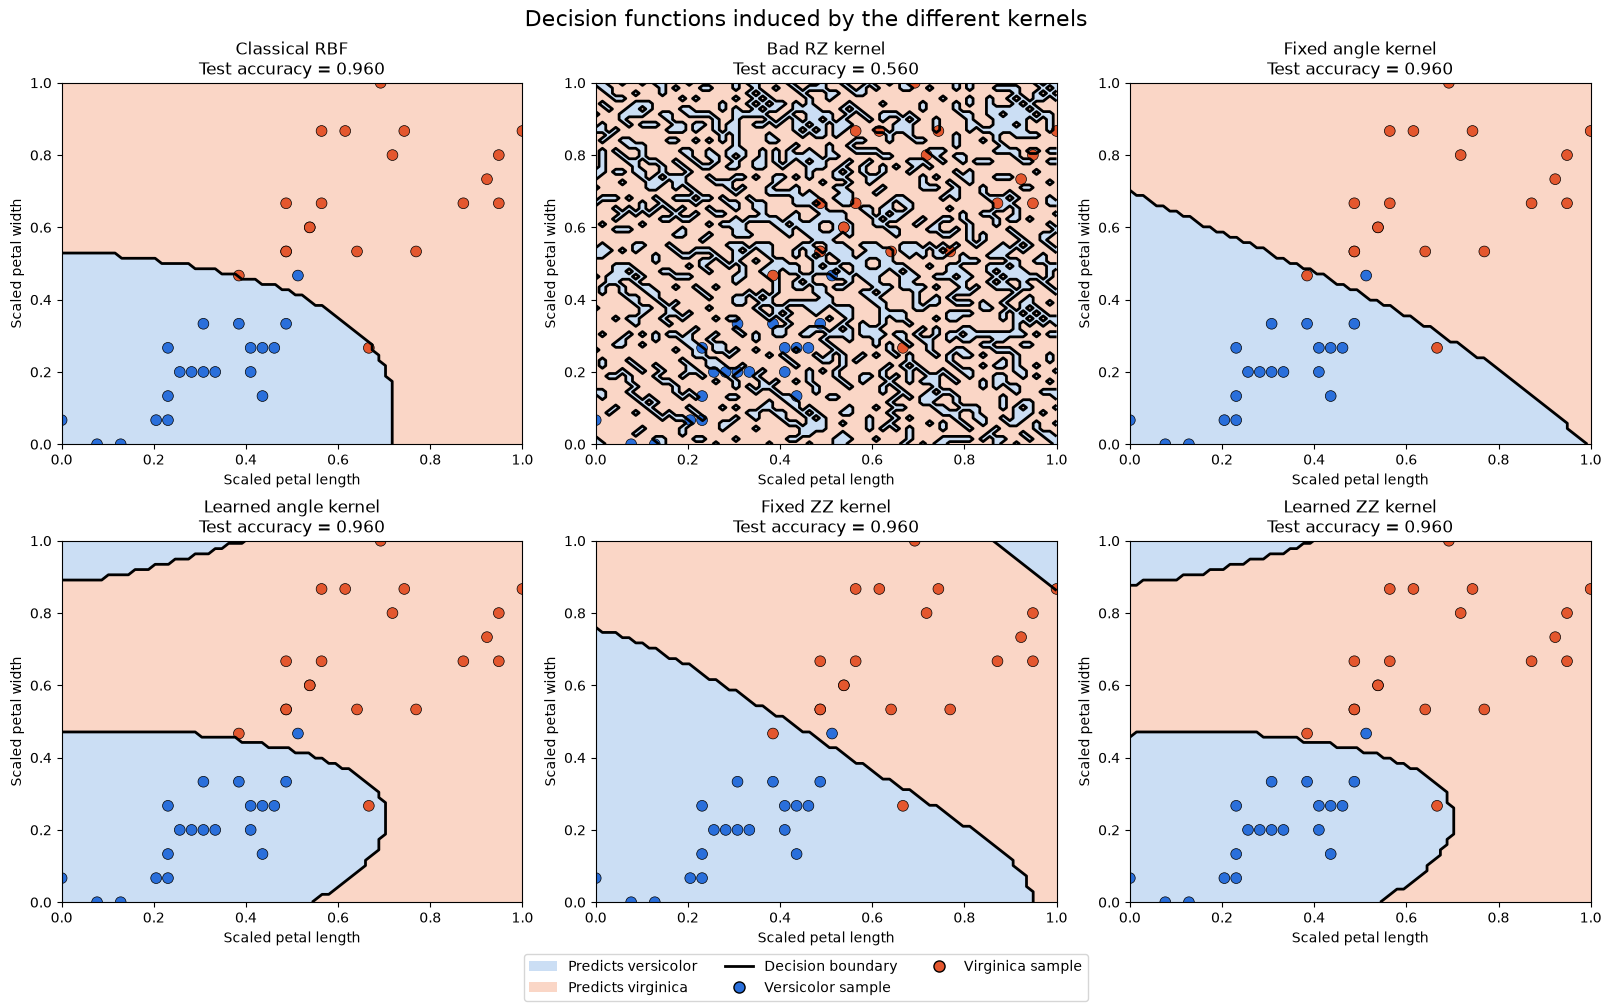

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for ax, (model_name, grid_predictions) in zip(axes, decision_region_predictions.items()):
    ax.contourf(decision_petal_length, decision_petal_width, grid_predictions, levels=[-0.5, 0.5, 1.5], colors=["#8CB7E8", "#F4A582"], alpha=0.45)

    if np.unique(grid_predictions).size > 1:
        ax.contour(decision_petal_length, decision_petal_width, grid_predictions, levels=[0.5], colors="black", linewidths=2.0)

    sns.scatterplot(x=X_kernel_train[:, 0], y=X_kernel_train[:, 1], hue=y_kernel_train, palette=CLASS_COLORS, edgecolor="black", linewidth=0.5, s=60, legend=False, ax=ax)

    test_accuracy = classification_performance.loc[classification_performance["Model"] == model_name, "Test accuracy"].iloc[0]

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Scaled petal length")
    ax.set_ylabel("Scaled petal width")
    ax.set_title(f"{model_name}\nTest accuracy = {test_accuracy:.3f}")

legend_handles = [
    Patch(facecolor="#8CB7E8", alpha=0.45, label="Predicts versicolor"),
    Patch(facecolor="#F4A582", alpha=0.45, label="Predicts virginica"),
    Line2D([0], [0], color="black", linewidth=2.0, label="Decision boundary"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=CLASS_COLORS[0], markeredgecolor="black", markersize=8, label="Versicolor sample"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=CLASS_COLORS[1], markeredgecolor="black", markersize=8, label="Virginica sample"),
]

fig.legend(handles=legend_handles, loc="outside lower center", ncol=3, frameon=True)
fig.suptitle("Decision functions induced by the different kernels", fontsize=16)

plt.show()

# What should we take away?

## The kernel is proposed, not discovered from nothing

We begin with assumptions about useful similarity: smoothness, periodicity, quantization, normalization, or interactions.

These assumptions motivate an encoding architecture. Validation can select among proposed encodings, and kernel training can select parameters within one encoding.

Neither procedure searches over every possible kernel.

## The classifier does not infer the kernel formula

The encoding and fidelity rule determine

$$
K_\phi(x,z)
=
\left|
\langle 0|
U_\phi(x)^\dagger U_\phi(z)
|0\rangle
\right|^2.
$$

The SVM receives evaluations of this function and learns coefficients $\alpha_i$ and an intercept $b$.

## The encoding and classifier are interdependent

Changing the encoding changes the Gram matrix. Changing the Gram matrix changes the support vectors, SVM coefficients, margin, and decision boundary.

When the encoding is trainable, the classifier-dependent loss supplies feedback for updating the encoding parameters. Nevertheless, training remains restricted to the kernel family defined by the circuit.

The bad $R_Z$ encoding makes the limitation exact:

$$
U_{\mathrm{bad}}(x)|00\rangle
=
e^{i\gamma(x)}|00\rangle
\quad\Longrightarrow\quad
K_{\mathrm{bad}}(x,z)=1
\quad\Longrightarrow\quad
f_{\mathrm{bad}}(x)=b.
$$

Once the encoding erases the distinction between the inputs, no kernel classifier can recover it.

The complete relationship is

$$
\text{encoding architecture}
\longrightarrow
\text{kernel family}
\longrightarrow
\text{learned kernel}
\longrightarrow
\text{decision function}.
$$

The architecture determines what can be learned. The training procedure determines what is learned within that architecture.